In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [9]:
df.drop(['RowNumber', 'CustomerId', 'Surname'] , axis = 1,  inplace = True)

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


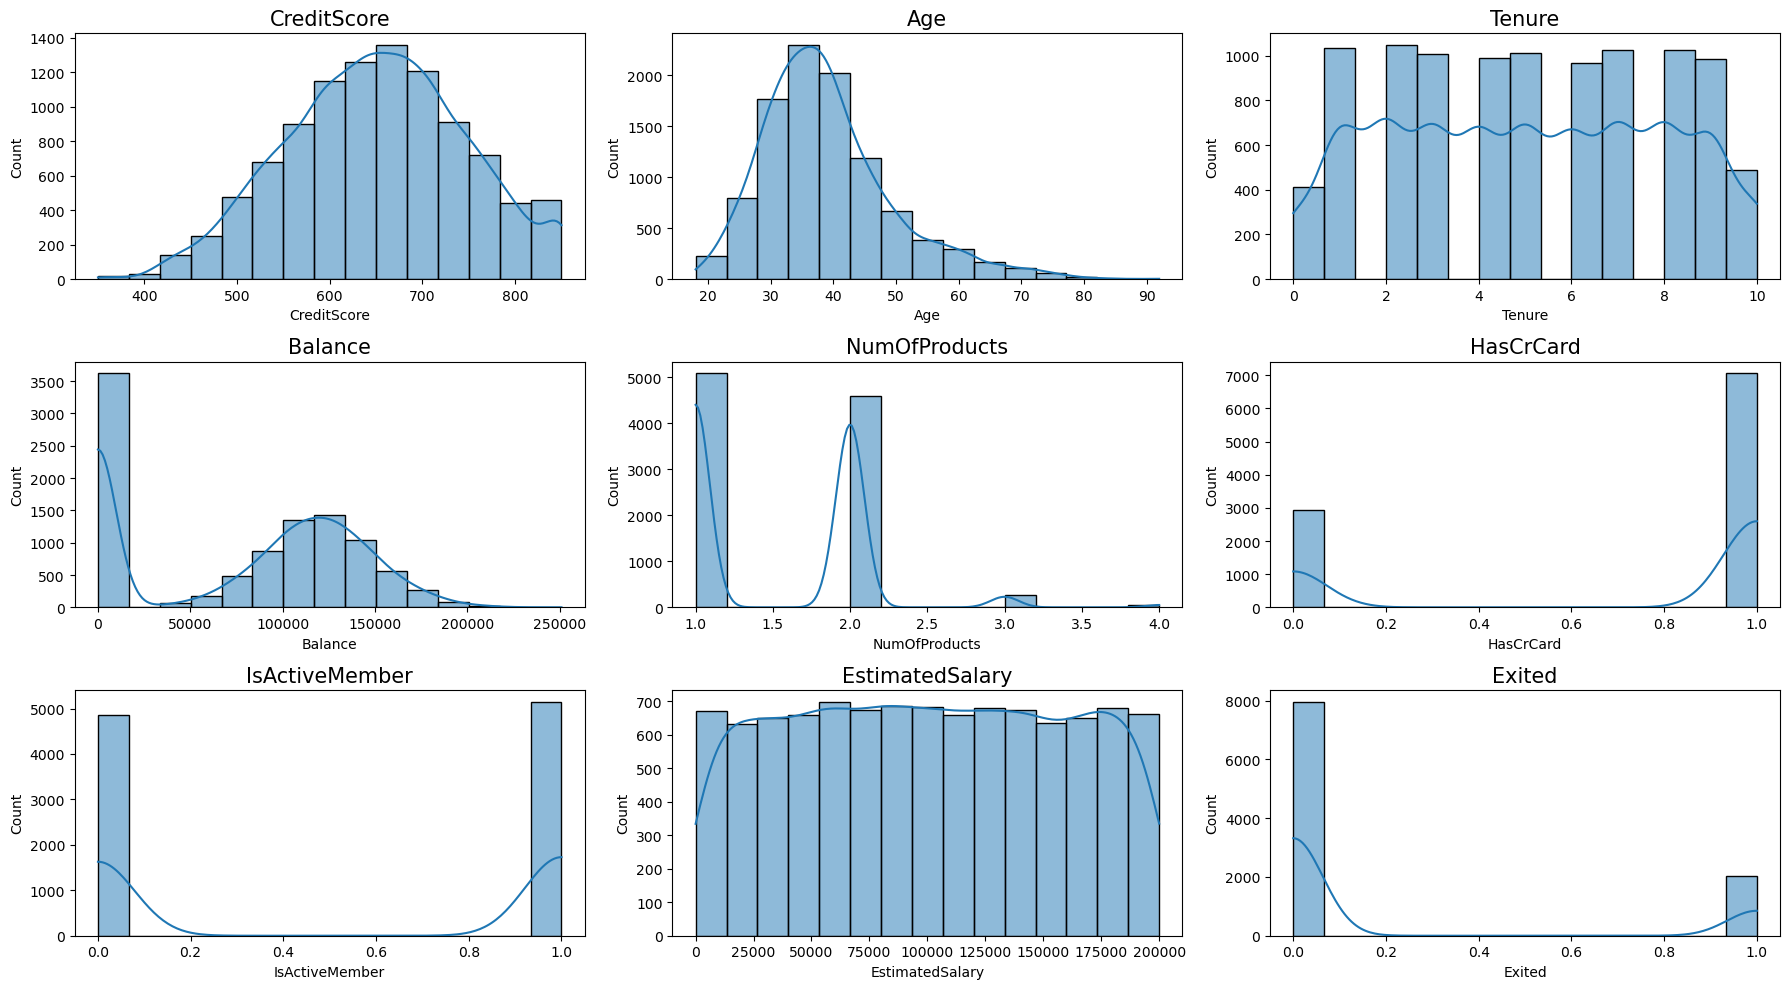

In [11]:
plt.figure(figsize = (18 , 10))

def plotting(var , num):
    plt.subplot(3 , 3 , num)
    sns.histplot(df[var] , bins = 15 , kde = True)
    plt.title(var , fontsize = 15)

plotting('CreditScore' , 1)
plotting('Age' , 2)
plotting('Tenure' , 3)
plotting('Balance' , 4)
plotting('NumOfProducts' , 5)
plotting('HasCrCard' , 6)
plotting('IsActiveMember' , 7)
plotting('EstimatedSalary' , 8)
plotting('Exited' , 9)

plt.tight_layout()
plt.show()

In [12]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [13]:
#in balancing 0 with seperate with another columns
df['Balance_zero'] = (df['Balance'] == 0).astype(int)
df['Balance'] = np.log1p(df['Balance'])

#in age there are also in frequently inbalnced 
#in age i do create a columns nd labeling
df['Age_Group'] = pd.cut(
    df['Age'],
    bins = [18 , 30 , 45 , 60 , 100],
    labels= ['Young' , 'Adult' , 'Midage' ,'Senior']
)

#in numOfPrduct there are also inblance
df['ProductCategory'] = df['NumOfProducts'].replace({
    1: 'One',
    2: 'Two',
    3: 'ThreePlus',
    4: 'ThreePlus'
})

# in Exited are also inbalance data 
# using balanced method and if accuray are down,  then use smote method

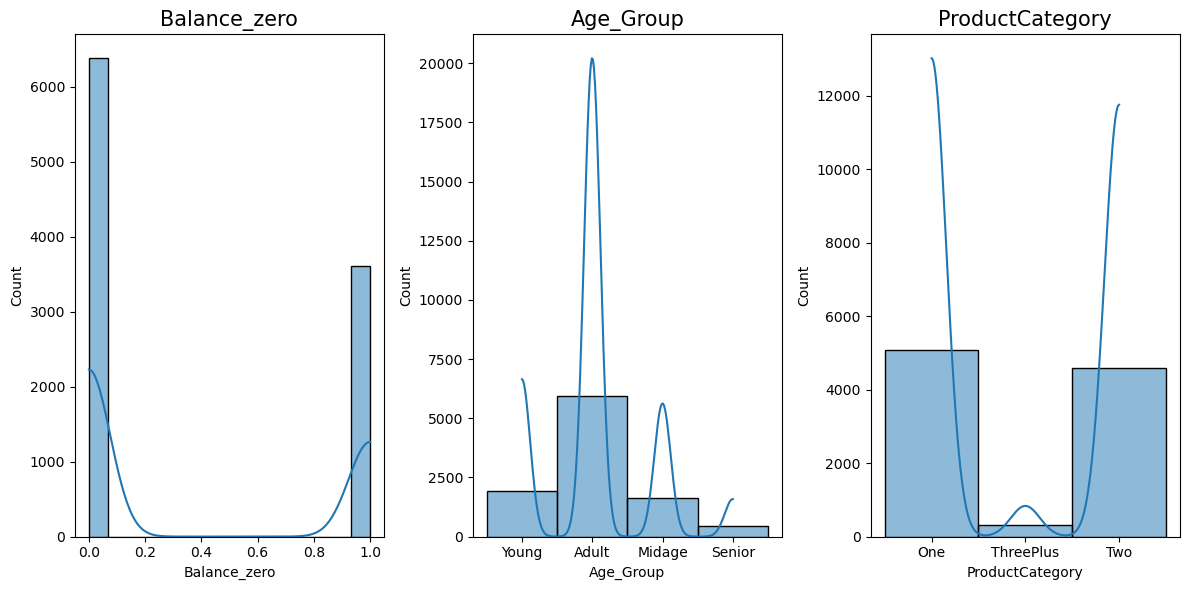

In [14]:
plt.figure(figsize = (12 , 6))

def plotting(var , num):
    plt.subplot(1 , 3 , num)
    sns.histplot(df[var] , bins = 15 , kde = True)
    plt.title(var , fontsize = 15)

plotting('Balance_zero' , 1)
plotting('Age_Group' , 2)
plotting('ProductCategory' , 3)

plt.tight_layout()
plt.show()

In [15]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_zero,Age_Group,ProductCategory
0,619,France,Female,42,2,0.000000,1,1,1,101348.88,1,1,Adult,One
1,608,Spain,Female,41,1,11.336294,1,0,1,112542.58,0,0,Adult,One
2,502,France,Female,42,8,11.980813,3,1,0,113931.57,1,0,Adult,ThreePlus
3,699,France,Female,39,1,0.000000,2,0,0,93826.63,0,1,Adult,Two
4,850,Spain,Female,43,2,11.740155,1,1,1,79084.10,0,0,Adult,One


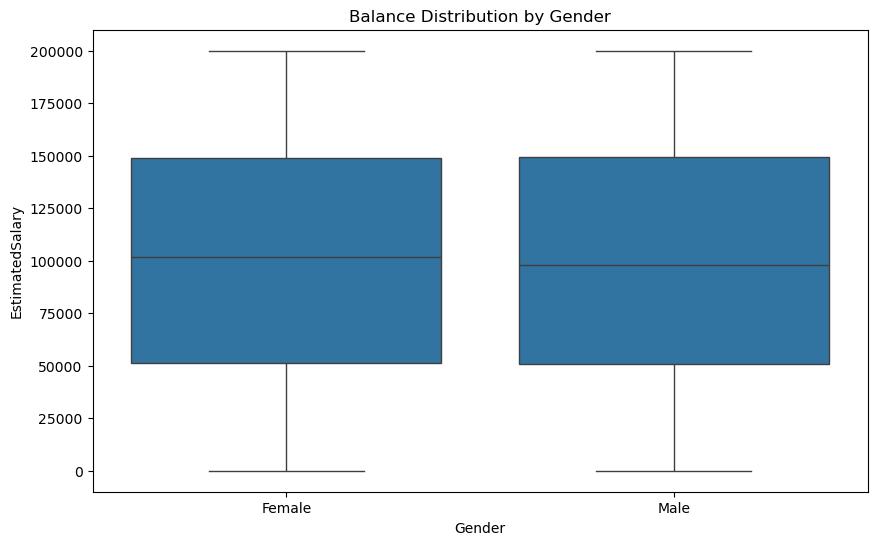

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Gender'], y=df['EstimatedSalary'])
plt.title('Balance Distribution by Gender')
plt.show()

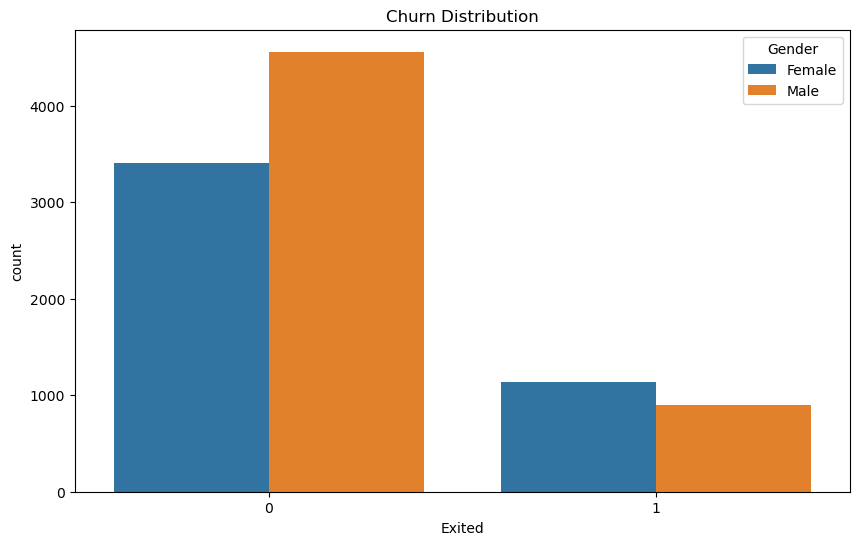

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(x='Exited', data=df , hue = 'Gender')
plt.title('Churn Distribution')
plt.show()

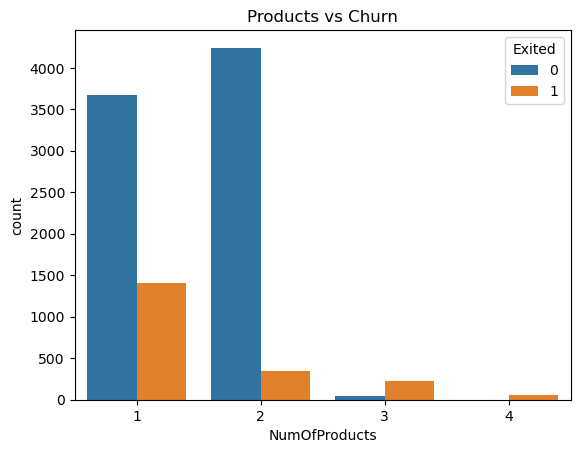

In [18]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.title('Products vs Churn')
plt.show()

Text(0.5, 1.0, 'Feature Correlation')

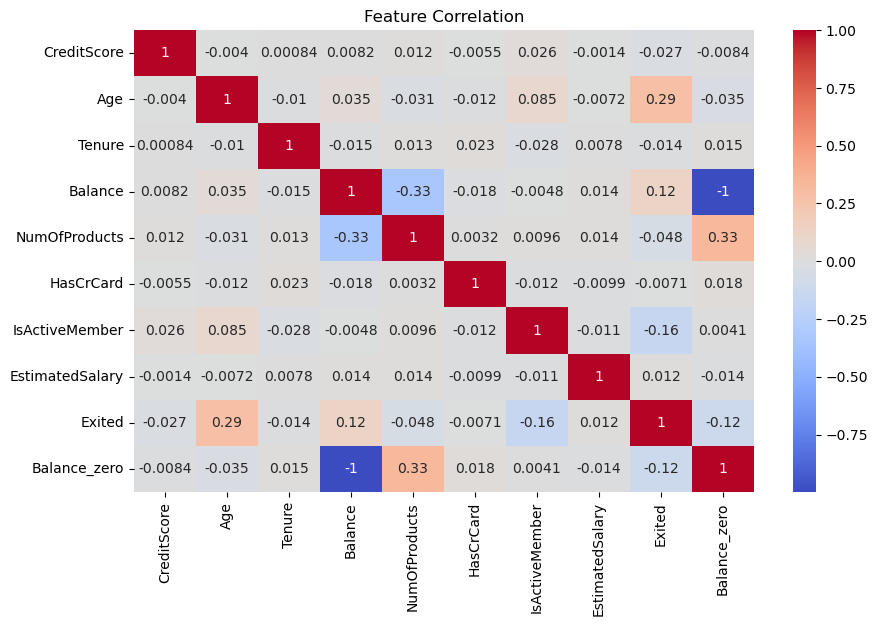

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')

In [20]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

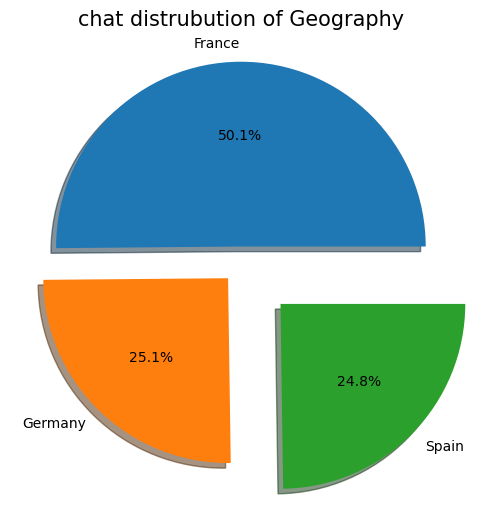

In [21]:
plt.figure(figsize=(12 ,6))
count = df['Geography'].value_counts()

plt.pie(count ,
       labels = count.index ,
        autopct= '%.1f%%',
        shadow = True,
        explode = [0.1 , 0.1 , 0.3]
)

plt.title('chat distrubution of Geography' , fontsize = 15)
plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      10000 non-null  int64   
 1   Geography        10000 non-null  object  
 2   Gender           10000 non-null  object  
 3   Age              10000 non-null  int64   
 4   Tenure           10000 non-null  int64   
 5   Balance          10000 non-null  float64 
 6   NumOfProducts    10000 non-null  int64   
 7   HasCrCard        10000 non-null  int64   
 8   IsActiveMember   10000 non-null  int64   
 9   EstimatedSalary  10000 non-null  float64 
 10  Exited           10000 non-null  int64   
 11  Balance_zero     10000 non-null  int64   
 12  Age_Group        9978 non-null   category
 13  ProductCategory  10000 non-null  object  
dtypes: category(1), float64(2), int64(8), object(3)
memory usage: 1.0+ MB


In [23]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_zero,Age_Group,ProductCategory
0,619,France,Female,42,2,0.000000,1,1,1,101348.88,1,1,Adult,One
1,608,Spain,Female,41,1,11.336294,1,0,1,112542.58,0,0,Adult,One
2,502,France,Female,42,8,11.980813,3,1,0,113931.57,1,0,Adult,ThreePlus
3,699,France,Female,39,1,0.000000,2,0,0,93826.63,0,1,Adult,Two
4,850,Spain,Female,43,2,11.740155,1,1,1,79084.10,0,0,Adult,One


In [24]:
df['Age_Group'].value_counts()

Age_Group
Adult     5921
Young     1946
Midage    1647
Senior     464
Name: count, dtype: int64

In [25]:
#lable Encoding and on hot encoding
# lb-> gender 
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
df['Gender'] = lb.fit_transform(df['Gender'])

# Correct column lists
num_col = ['CreditScore', 'Age', 'Tenure', 'Balance',
           'NumOfProducts', 'HasCrCard', 'IsActiveMember',
           'EstimatedSalary', 'Balance_zero']

cat_col = ['Geography', 'Age_Group', 'ProductCategory']  

# Column Transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_col),
        ('num', StandardScaler(), num_col)
    ]
)

In [26]:
# useign pipeline and traied the model on logistiRegressiom
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline(steps=[
    ('prepprocessing' , preprocessor),
    ('model' , LogisticRegression(class_weight = 'balanced'))
])

In [27]:
#  train and test the model
from sklearn.model_selection import train_test_split
x = df.drop(['Exited'] , axis = 1)
y = df['Exited']

x_train , x_test , y_train , y_test  = train_test_split(x , y , test_size = 0.2 , random_state= 42 , shuffle= True)


In [28]:
# predicting score by based on LR alogorithums
pipeline.fit(x_train , y_train)
y_pred = pipeline.predict(x_test)
print('Predicated value :' , y_pred[:10].round(2))

Predicated value : [0 0 0 1 0 0 1 0 1 1]


In [29]:
# score by based on LR alogorithums
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score ,f1_score, confusion_matrix

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:\n", accuracy_score(y_test, y_pred))
print("Precision Score:\n", precision_score(y_test, y_pred))
print("F1 Score:\n", f1_score(y_test, y_pred))
print("REcall Score:\n", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.77      0.84      1607
           1       0.45      0.75      0.56       393

    accuracy                           0.77      2000
   macro avg       0.69      0.76      0.70      2000
weighted avg       0.83      0.77      0.79      2000

Accuracy Score:
 0.768
Precision Score:
 0.4464555052790347
F1 Score:
 0.5606060606060606
REcall Score:
 0.7531806615776081
Confusion Matrix:
 [[1240  367]
 [  97  296]]


In [30]:
# # assinging the model with pipeline of RFC
from sklearn.ensemble import RandomForestClassifier
pipeline_R =Pipeline(steps = [
    ('preprocessing' , preprocessor),
    ('model_R'  , RandomForestClassifier(class_weight='balanced' ,n_estimators= 100 , max_depth= None , criterion='gini'))
]) 

In [31]:
# # predicting score by based on RFC alogorithums
pipeline_R.fit(x_train , y_train)
R_pred = pipeline_R.predict(x_test)
print('Predicated VAlue : ' , R_pred[:10].round(2))

Predicated VAlue :  [0 0 0 0 0 0 0 0 0 0]


In [32]:
#score by based on RFC alogorithums
print("Classification Report:\n", classification_report(y_test, R_pred))
print("Accuracy Score:\n", accuracy_score(y_test, R_pred))
print("Precision Score:\n", precision_score(y_test, R_pred))
print("F1 Score:\n", f1_score(y_test, R_pred))
print("REcall Score:\n", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, R_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.44      0.56       393

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000

Accuracy Score:
 0.861
Precision Score:
 0.7467811158798283
F1 Score:
 0.5559105431309904
REcall Score:
 0.7531806615776081
Confusion Matrix:
 [[1548   59]
 [ 219  174]]


In [33]:
# # assinging the model with pipeline of XGB
from xgboost import XGBClassifier
pipline_X =Pipeline(steps = [
    ('preprocessing' , preprocessor),
    ('model' , XGBClassifier(
        class_weight = 'balanced',
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=7963/2037,  
        random_state=42
    ))
])

In [34]:
# # predicting score by based on XGB alogorithums
pipline_X.fit(x_train, y_train)
x_pred = pipline_X.predict(x_test)
print('Predication Score : ' , x_pred[:10].round(2))


Predication Score :  [0 0 0 1 0 0 0 1 1 1]


In [35]:
#score by based on XGB alogorithums
print("Classification Report:\n", classification_report(y_test, x_pred))
print("Accuracy Score:\n", accuracy_score(y_test, x_pred))
print("Precision Score:\n", precision_score(y_test, x_pred))
print("F1 Score:\n", f1_score(y_test, x_pred))
print("Recall Score:\n", recall_score(y_test, x_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, x_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.84      0.88      1607
           1       0.52      0.72      0.61       393

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.74      2000
weighted avg       0.85      0.82      0.83      2000

Accuracy Score:
 0.817
Precision Score:
 0.5249537892791127
F1 Score:
 0.6081370449678801
Recall Score:
 0.72264631043257
Confusion Matrix:
 [[1350  257]
 [ 109  284]]


In [39]:
# using SMOTE alogoritum to use on XBG to imporved f1 and recall score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
pipeline_SX = Pipeline([
    ('preprocessing' , preprocessor),
    ('smote' , SMOTE(random_state = 42 , sampling_strategy = 'auto')),
    ('model' , XGBClassifier(
        random_state=42
    ))
])


In [40]:
# predict with XBR with SMOte
pipeline_SX.fit(x_train , y_train)
SX_pred =  pipeline_SX.predict(x_test)
print('Pediction : ' , SX_pred[:10].round(2))

# score with XBR with SMOte
print("Classification Report:\n", classification_report(y_test, SX_pred))
print("Accuracy Score:\n", accuracy_score(y_test, SX_pred))
print("Precision Score:\n", precision_score(y_test, SX_pred))
print("F1 Score:\n", f1_score(y_test, SX_pred))
print("Recall Score:\n", recall_score(y_test, SX_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, SX_pred))

Pediction :  [0 0 0 0 0 0 0 0 0 0]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91      1607
           1       0.65      0.55      0.60       393

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.85      0.85      0.85      2000

Accuracy Score:
 0.854
Precision Score:
 0.6525679758308157
F1 Score:
 0.5966850828729282
Recall Score:
 0.549618320610687
Confusion Matrix:
 [[1492  115]
 [ 177  216]]


In [38]:
## The model was gone with XGBBoost with Smote


In [ ]:
# to find most f1 score 
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    pipeline_SX,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
grid_search.fit(x_train , y_train)

In [60]:
result = grid_search.cv_results_

In [62]:
result = pd.DataFrame(grid_search.cv_results_)
result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__colsample_bytree,param_model__learning_rate,param_model__max_depth,param_model__n_estimators,param_model__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.270717,0.028077,0.017968,0.003674,0.6,0.03,3,100,0.6,"{'model__colsample_bytree': 0.6, 'model__learn...",0.598621,0.611570,0.644562,0.590206,0.590426,0.607077,0.020292,192
1,0.265997,0.022040,0.017009,0.002875,0.6,0.03,3,100,0.8,"{'model__colsample_bytree': 0.6, 'model__learn...",0.610028,0.607978,0.648721,0.585427,0.586345,0.607700,0.022980,186
2,0.218966,0.023029,0.017956,0.003137,0.6,0.03,3,100,1.0,"{'model__colsample_bytree': 0.6, 'model__learn...",0.606488,0.611342,0.649596,0.593909,0.590296,0.610326,0.021112,157
3,0.489863,0.062433,0.020728,0.002067,0.6,0.03,3,200,0.6,"{'model__colsample_bytree': 0.6, 'model__learn...",0.605797,0.610556,0.652720,0.601290,0.591892,0.612451,0.021055,129
4,0.470771,0.052262,0.021123,0.001998,0.6,0.03,3,200,0.8,"{'model__colsample_bytree': 0.6, 'model__learn...",0.600289,0.615603,0.657343,0.597169,0.588874,0.611855,0.024334,144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,1.879752,0.579809,0.051068,0.030359,1.0,0.10,7,200,0.8,"{'model__colsample_bytree': 1.0, 'model__learn...",0.588034,0.590909,0.621035,0.602484,0.564103,0.593313,0.018652,232
239,1.676147,0.579891,0.040443,0.020002,1.0,0.10,7,200,1.0,"{'model__colsample_bytree': 1.0, 'model__learn...",0.601036,0.584775,0.635897,0.594855,0.566494,0.596612,0.022861,225
240,2.220747,0.124390,0.057971,0.012295,1.0,0.10,7,300,0.6,"{'model__colsample_bytree': 1.0, 'model__learn...",0.580311,0.580756,0.625205,0.572741,0.543624,0.580527,0.026148,243
241,2.803595,0.544980,0.032860,0.006818,1.0,0.10,7,300,0.8,"{'model__colsample_bytree': 1.0, 'model__learn...",0.581315,0.595819,0.618487,0.585670,0.553846,0.587027,0.020988,238


In [63]:
result[[param_model__colsample_bytree'	,'param_model__learning_rate'	,'param_model__max_depth'	,'param_model__n_estimators'	,'param_model__subsample'	,'mean_test_score']]

,param_model__colsample_bytree,param_model__learning_rate,param_model__max_depth,param_model__n_estimators,param_model__subsample,mean_test_score
0,0.6,0.03,3,100,0.6,0.607077
1,0.6,0.03,3,100,0.8,0.607700
2,0.6,0.03,3,100,1.0,0.610326
3,0.6,0.03,3,200,0.6,0.612451
4,0.6,0.03,3,200,0.8,0.611855
...,...,...,...,...,...,...
238,1.0,0.10,7,200,0.8,0.593313
239,1.0,0.10,7,200,1.0,0.596612
240,1.0,0.10,7,300,0.6,0.580527
241,1.0,0.10,7,300,0.8,0.587027


In [65]:
# find best of this df
print('Best Param : \n' , grid_search.best_params_)
print('Best F1 Score : \n' , grid_search.best_score_)

Best Param : 
 {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.6}
Best F1 Score : 
 0.627375904921756


In [69]:
# find best of the model on calssification report
best_model = grid_search.best_estimator_
best_pred = best_model.predict(x_test)
print('Predict : ' , best_pred[:5].round(5))

print('Classification report : \n' , classification_report(y_test ,best_pred))
print("Accuracy Score:\n", accuracy_score(y_test, best_pred))
print("Precision Score:\n", precision_score(y_test, best_pred))
print("F1 Score:\n", f1_score(y_test, best_pred))
print("Recall Score:\n", recall_score(y_test, best_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, best_pred))

Predict :  [0 0 0 1 0]
Classification report : 
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      1607
           1       0.64      0.62      0.63       393

    accuracy                           0.86      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      0.86      0.86      2000

Accuracy Score:
 0.856
Precision Score:
 0.6363636363636364
F1 Score:
 0.6298200514138818
Recall Score:
 0.6234096692111959
Confusion Matrix:
 [[1467  140]
 [ 148  245]]


In [ ]:
# grapgh of roc_curve with auc score

In [75]:
y_prob = best_model.predict_proba(x_test)[:, 1]

In [80]:
from sklearn.metrics import roc_curve , auc
fpr , tpr , thresholds = roc_curve(y_test , y_pred)
roc_auc = auc(fpr , tpr)

print('AUC Score : '  , roc_auc)

AUC Score :  0.6992000646028587


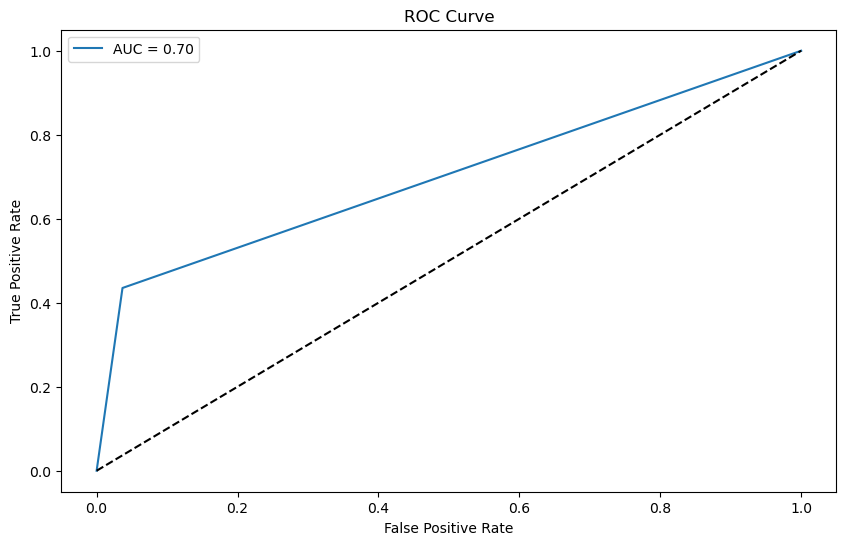

In [81]:
plt.figure(figsize = (10 , 6)) 
plt.plot(fpr , tpr , label = f"AUC = {roc_auc:.2f}")
plt.plot([0 , 1]  , [0 , 1] ,'k--')


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [82]:
# grapg b\w recall and precison
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

ap_score = average_precision_score(y_test, y_prob)

print("Average Precision (AP):", ap_score)


Average Precision (AP): 0.6838603458363068


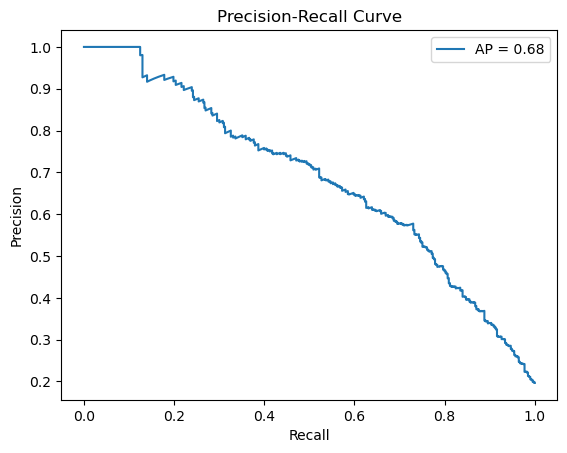

In [83]:
import matplotlib.pyplot as plt

plt.plot(recall, precision, label=f"AP = {ap_score:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [85]:
# importing my pipeline of XGBBoots with Smote in pkl form,
import joblib
joblib.dump(best_model , 'churn_model.pkl')

['churn_model.pkl']